# 💬 Customer Feedback Sentiment Analysis

Scoring and labelling **97 customer reviews** with machine learning.

The pipeline is a small **knowledge-distillation** setup: a pretrained
transformer labels the reviews, then a lightweight TF-IDF + linear model is
trained to reproduce those labels so the analysis runs without a deep-learning
stack. See [`docs/sentiment_methodology.md`](../docs/sentiment_methodology.md)
for the full write-up.

## 0. Setup

In [1]:
%matplotlib inline
import json
import pathlib
import sys

ROOT = pathlib.Path.cwd()
if not (ROOT / "src").is_dir() and (ROOT.parent / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import feedback_visualization, word_analysis
from src.config import SENTIMENT_METRICS_FILE
from src.data_loader import load_feedback
from src.sentiment import LexiconSentimentScorer, get_default_scorer

pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_colwidth", 90)
print("Project root:", ROOT)

Project root: D:\portfolio\Insurance Data Analysis


## 1. Load the feedback

In [2]:
feedback = load_feedback(ROOT / "data" / "customer_feedback.csv")
print(f"Reviews: {len(feedback):,}")
feedback.head()

Reviews: 97


,Customer Name,Feedback
0,John Smith,"Excellent service, very satisfied with my policy."
1,Jane Doe,"Had an issue with claim processing, but it was resolved quickly."
2,Emily Johnson,"Very helpful customer service, answered all my questions."
3,Michael Brown,"Premiums are a bit high, but overall a good experience."
4,Sarah Davis,Fast and efficient claims process.


## 2. Score and label every review

The default scorer is the distilled sklearn model (`models/sentiment_model.joblib`),
so no GPU or transformer download is required.

In [3]:
scorer = get_default_scorer()
print("Scoring engine:", scorer.name)

scored = feedback.copy()
scored["sentiment_score"] = scorer.score(scored["Feedback"])
scored["sentiment_label"] = scored["sentiment_score"].map(
    lambda value: "Excellent" if value >= 0.80 else ("Good" if value > 0.50 else "Needs Improvement")
)
display(scored["sentiment_label"].value_counts().to_frame("Reviews"))
scored.head(8)

Scoring engine: sklearn


,Reviews
sentiment_label,
Excellent,53
Needs Improvement,34
Good,10


,Customer Name,Feedback,sentiment_score,sentiment_label
0,John Smith,"Excellent service, very satisfied with my policy.",0.933,Excellent
1,Jane Doe,"Had an issue with claim processing, but it was resolved quickly.",0.503,Good
2,Emily Johnson,"Very helpful customer service, answered all my questions.",0.864,Excellent
3,Michael Brown,"Premiums are a bit high, but overall a good experience.",0.929,Excellent
4,Sarah Davis,Fast and efficient claims process.,0.898,Excellent
5,David Wilson,"Policy options are confusing, need better explanations.",0.125,Needs Improvement
6,Laura Martinez,"Great value for money, highly recommend.",0.902,Excellent
7,Robert Anderson,"Long wait times on the phone, need improvement.",0.095,Needs Improvement


## 3. Sentiment charts

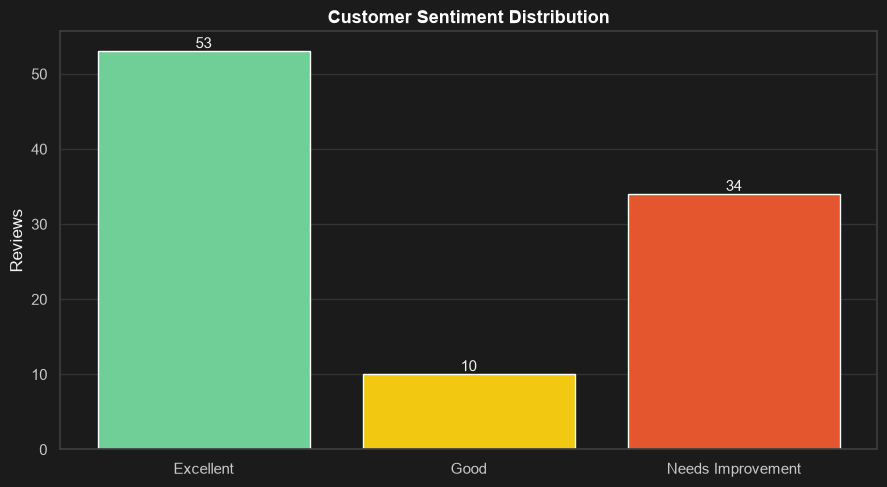

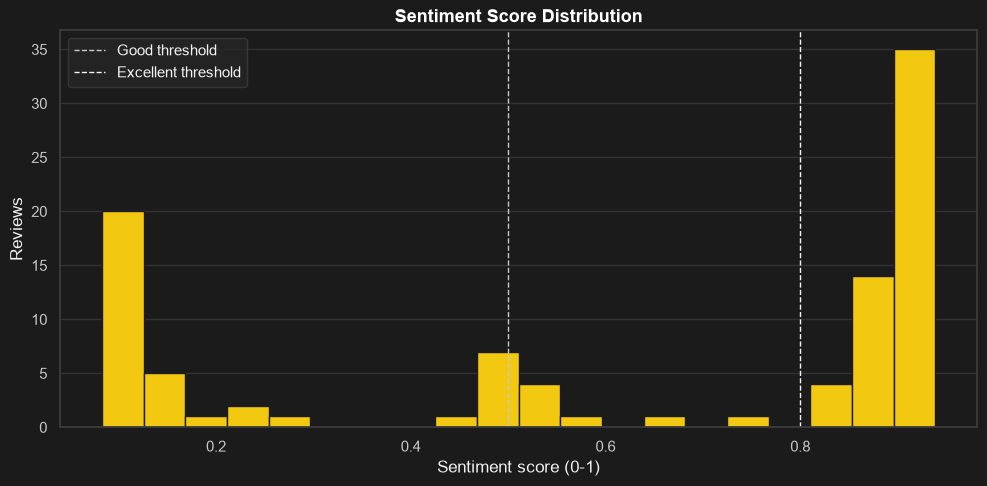

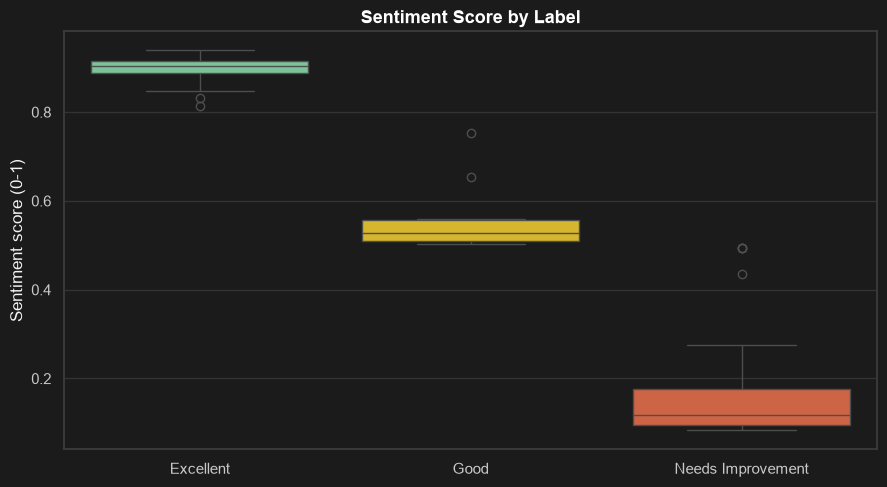

In [4]:
feedback_visualization.plot_sentiment_distribution(scored["sentiment_label"]);
feedback_visualization.plot_score_histogram(scored["sentiment_score"]);
feedback_visualization.plot_score_by_label(scored);

## 4. What are customers talking about?

Word clouds for the whole feedback set, then split by sentiment.

,frequency
service,22
policy,21
satisfied,15
customer,13
process,12
need,10
options,9
claim,9
great,9
coverage,9


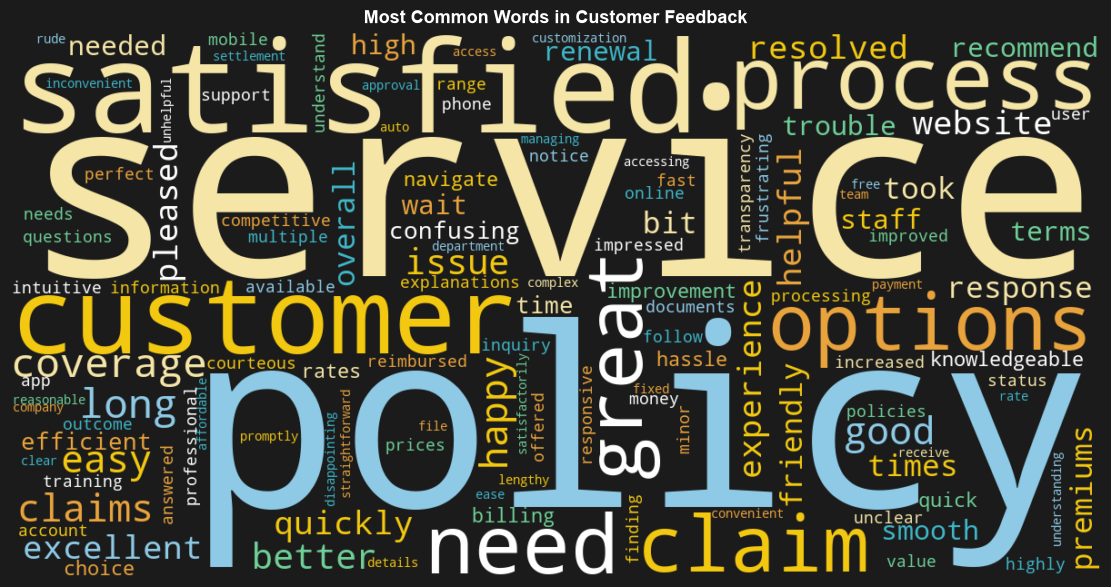

In [5]:
all_words = word_analysis.word_frequencies(scored["Feedback"])
display(all_words.head(15).to_frame("frequency"))
word_analysis.plot_wordcloud(
    all_words, "feedback_04_wordcloud_all.png", "Most Common Words in Customer Feedback"
);

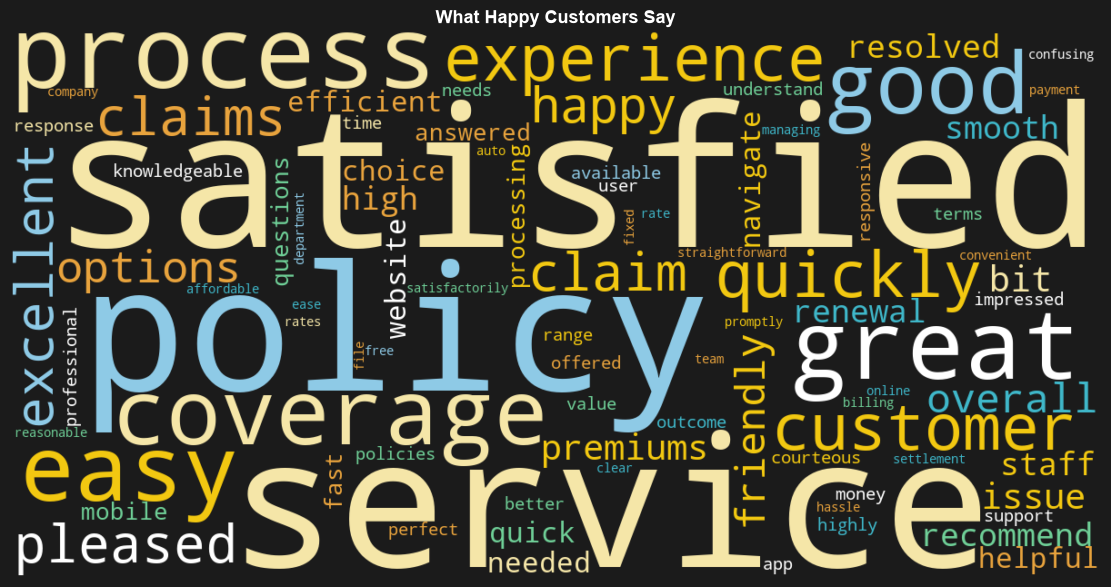

In [6]:
positive = word_analysis.word_frequencies(
    scored.loc[scored["sentiment_label"].isin(["Excellent", "Good"]), "Feedback"]
)
word_analysis.plot_wordcloud(
    positive, "feedback_05_wordcloud_positive.png", "What Happy Customers Say"
);

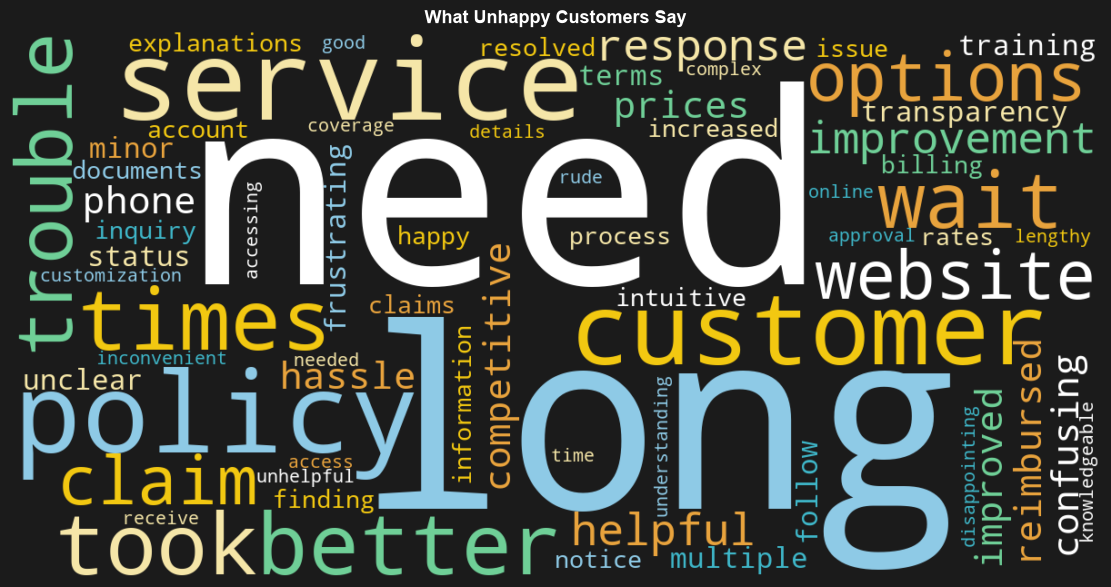

In [7]:
negative = word_analysis.word_frequencies(
    scored.loc[scored["sentiment_label"] == "Needs Improvement", "Feedback"]
)
word_analysis.plot_wordcloud(
    negative, "feedback_06_wordcloud_negative.png", "What Unhappy Customers Say"
);

## 5. How good is the model?

In [8]:
metrics = json.loads(pathlib.Path(SENTIMENT_METRICS_FILE).read_text())
print("Teacher:", metrics["teacher"], "| reviews:", metrics["dataset_size"])
display(pd.DataFrame(metrics["candidates"]))
print("Best:", metrics["best"])

Teacher: transformer | reviews: 97


,vectorizer,classifier,accuracy,macro_f1
0,char,linearsvc,0.897,0.865
1,char,logreg,0.897,0.865
2,word,complementnb,0.876,0.845
3,char,complementnb,0.876,0.835
4,word,linearsvc,0.866,0.824
5,word,logreg,0.835,0.797


Best: {'vectorizer': 'char', 'classifier': 'linearsvc', 'accuracy': 0.8969, 'macro_f1': 0.8649}


The best candidate is **char TF-IDF + LinearSVC** with **~90% accuracy** and a
**0.86 macro F1** against the transformer teacher, on 5-fold cross-validation.

## 6. Sanity check against the VADER lexicon

In [9]:
vader = LexiconSentimentScorer().score(scored["Feedback"])
comparison = pd.DataFrame(
    {"sklearn_score": scored["sentiment_score"], "vader_score": vader}
)
print("Pearson correlation:", round(comparison["sklearn_score"].corr(comparison["vader_score"]), 3))
comparison.head(8)

Pearson correlation: 0.742


,sklearn_score,vader_score
0,0.933,0.889
1,0.503,0.631
2,0.864,0.738
3,0.929,0.796
4,0.898,0.711
5,0.125,0.625
6,0.902,0.926
7,0.095,0.729


## 7. Key findings

- **Most reviews are positive** (~55% `Excellent`), but roughly a third fall
  into `Needs Improvement` — a meaningful signal for the retention team.
- The recurring themes are **service, policy options, claim processing and
  response times**.
- Happy customers talk about **fast, helpful, friendly service**; unhappy ones
  about **wait times, confusing policy options and slow claims**.
- The distilled model reproduces the transformer's labels with ~90% accuracy
  while running in milliseconds on CPU.

> The feedback is a synthetic sample used for demonstration.